In [12]:
import sys

print(sys.executable)

c:\Users\KESHAV\ML Project\Linear_Regression Project\.venv\Scripts\python.exe


In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [14]:
df = pd.read_csv("../../data/raw/AmesHousing.csv")

print("Shape:", df.shape)


df.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [15]:
df_fe = df.copy()

# -----------------------------
# Remove identifiers
# -----------------------------

df_fe = df_fe.drop(columns=["Order", "PID"])


# -----------------------------
# Total square footage
# -----------------------------

df_fe["TotalSF"] = (
    df_fe["Total Bsmt SF"].fillna(0)
    + df_fe["1st Flr SF"].fillna(0)
    + df_fe["2nd Flr SF"].fillna(0)
)


# -----------------------------
# Total bathrooms
# -----------------------------

df_fe["TotalBathrooms"] = (
    df_fe["Full Bath"].fillna(0)
    + 0.5 * df_fe["Half Bath"].fillna(0)
    + df_fe["Bsmt Full Bath"].fillna(0)
    + 0.5 * df_fe["Bsmt Half Bath"].fillna(0)
)


# -----------------------------
# Total porch/deck area
# -----------------------------

df_fe["TotalPorchSF"] = (
    df_fe["Wood Deck SF"].fillna(0)
    + df_fe["Open Porch SF"].fillna(0)
    + df_fe["Enclosed Porch"].fillna(0)
    + df_fe["3Ssn Porch"].fillna(0)
    + df_fe["Screen Porch"].fillna(0)
)


# -----------------------------
# Total finished basement area
# -----------------------------

df_fe["TotalBsmtFinSF"] = (
    df_fe["BsmtFin SF 1"].fillna(0)
    + df_fe["BsmtFin SF 2"].fillna(0)
)


# -----------------------------
# House age
# -----------------------------

df_fe["HouseAge"] = (
    df_fe["Yr Sold"]
    - df_fe["Year Built"]
)


# -----------------------------
# Years since remodel
# -----------------------------

df_fe["YearsSinceRemodel"] = (
    df_fe["Yr Sold"]
    - df_fe["Year Remod/Add"]
)


# -----------------------------
# Garage age
# -----------------------------

df_fe["GarageAge"] = (
    df_fe["Yr Sold"]
    - df_fe["Garage Yr Blt"]
)

print("Original shape:", df.shape)
print("Feature-engineered shape:", df_fe.shape)

Original shape: (2930, 82)
Feature-engineered shape: (2930, 87)


In [16]:
new_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "TotalBsmtFinSF",
    "HouseAge",
    "YearsSinceRemodel",
    "GarageAge"
]

df_fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalSF,2930.0,2546.269283,804.350838,334.0,2000.0,2450.0,2990.00,11752.0
TotalBathrooms,2930.0,2.217918,0.807444,1.0,1.5,2.0,2.50,7.0
TotalPorchSF,2930.0,182.891468,159.834420,0.0,48.0,165.0,266.00,1424.0
TotalBsmtFinSF,2930.0,492.183959,477.328254,0.0,0.0,459.5,808.00,5644.0
HouseAge,2930.0,36.434130,30.291357,-1.0,7.0,34.0,54.00,136.0
YearsSinceRemodel,2930.0,23.523891,20.858846,-2.0,4.0,15.0,42.75,60.0
GarageAge,2771.0,29.654637,25.569051,-200.0,6.0,28.0,48.00,114.0


In [18]:
correlation = (
    df_fe[new_features + ["SalePrice"]]
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

correlation

SalePrice            1.000000
TotalSF              0.793127
TotalBathrooms       0.636175
TotalBsmtFinSF       0.415550
TotalPorchSF         0.383506
GarageAge           -0.527634
YearsSinceRemodel   -0.534940
HouseAge            -0.558907
Name: SalePrice, dtype: float64

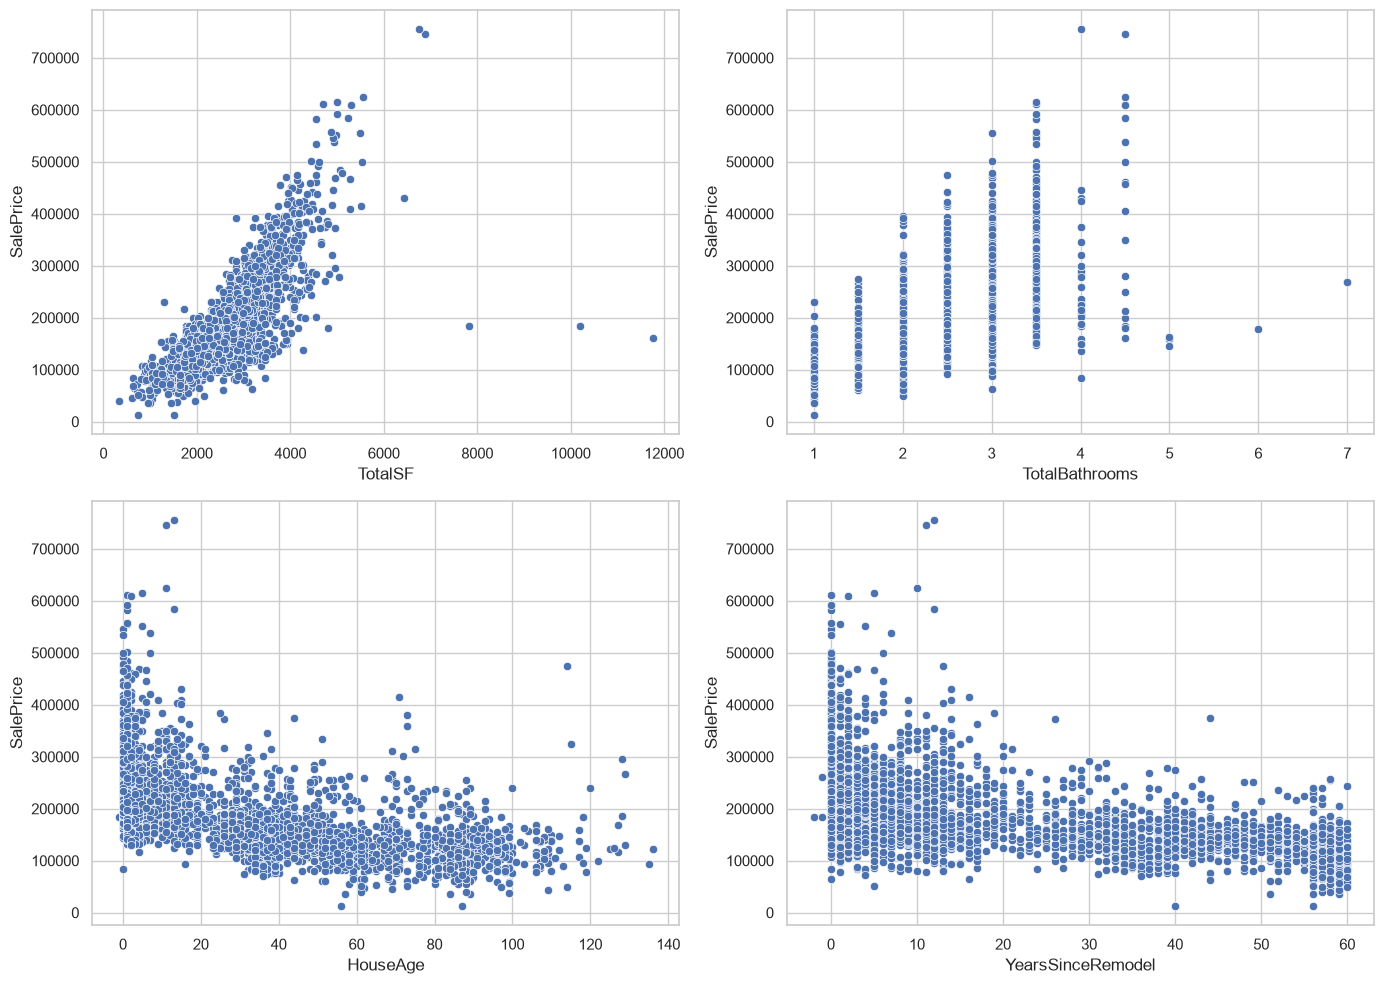

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(
    data=df_fe,
    x="TotalSF",
    y="SalePrice",
    ax=axes[0, 0]
)

sns.scatterplot(
    data=df_fe,
    x="TotalBathrooms",
    y="SalePrice",
    ax=axes[0, 1]
)

sns.scatterplot(
    data=df_fe,
    x="HouseAge",
    y="SalePrice",
    ax=axes[1, 0]
)

sns.scatterplot(
    data=df_fe,
    x="YearsSinceRemodel",
    y="SalePrice",
    ax=axes[1, 1]
)

plt.tight_layout()
plt.show()

In [23]:
print("Negative HouseAge:")
display(
    df_fe.loc[
        df_fe["HouseAge"] < 0,
        ["Year Built", "Yr Sold", "HouseAge"]
    ]
)

Negative HouseAge:


,Year Built,Yr Sold,HouseAge
2180,2008,2007,-1


In [26]:
# GarageAge has -200 This is more serious as that's clearly not legitimate garage age:
print("Negative YearsSinceRemodel:")
display(
    df_fe.loc[
        df_fe["YearsSinceRemodel"] < 0,
        ["Year Remod/Add", "Yr Sold", "YearsSinceRemodel"]
    ]
)

Negative YearsSinceRemodel:


,Year Remod/Add,Yr Sold,YearsSinceRemodel
1702,2008,2007,-1
2180,2009,2007,-2
2181,2008,2007,-1


In [27]:
print("Negative GarageAge:")
display(
    df_fe.loc[
        df_fe["GarageAge"] < 0,
        ["Garage Yr Blt", "Yr Sold", "GarageAge", "Garage Type"]
    ]
)

Negative GarageAge:


,Garage Yr Blt,Yr Sold,GarageAge,Garage Type
2180,2008.0,2007,-1.0,Attchd
2260,2207.0,2007,-200.0,Attchd


In [ ]:
# 1. HouseAge => correlation = -0.559
# Negative means: As house age increases, SalePrice tends to decrease.
# That's a useful engineered feature.

# 2. YearsSinceRemodel => correlation = -0.535
# Also makes sense: More years since the last remodel → generally lower SalePrice.

# 3. GarageAge => correlation = -0.528
# Again, older garages tend to correspond with lower prices.
# But don't trust this feature yet, because we have that -200 anomaly.

In [30]:
df_fe.loc[df_fe["HouseAge"] < 0, "HouseAge"] = np.nan
df_fe.loc[df_fe["YearsSinceRemodel"] < 0, "YearsSinceRemodel"] = np.nan
df_fe.loc[df_fe["GarageAge"] < 0, "GarageAge"] = np.nan

In [31]:
print("Negative HouseAge:",
      (df_fe["HouseAge"] < 0).sum())

print("Negative YearsSinceRemodel:",
      (df_fe["YearsSinceRemodel"] < 0).sum())

print("Negative GarageAge:",
      (df_fe["GarageAge"] < 0).sum())

Negative HouseAge: 0
Negative YearsSinceRemodel: 0
Negative GarageAge: 0


In [32]:
df_fe[["SalePrice", "TotalSF", "Gr Liv Area", "Lot Area"]
].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
SalePrice,2930.0,180796.060068,79886.692357,12789.0,61756.07,87500.0,129500.00,160000.0,213500.00,335000.0,456666.37,755000.0
TotalSF,2930.0,2546.269283,804.350838,334.0,1014.29,1510.9,2000.00,2450.0,2990.00,3933.1,4828.04,11752.0
Gr Liv Area,2930.0,1499.690444,505.508887,334.0,677.51,861.0,1126.00,1442.0,1742.75,2463.1,2930.66,5642.0
Lot Area,2930.0,10147.921843,7880.017759,1300.0,1680.00,3188.3,7440.25,9436.5,11555.25,17131.0,32988.92,215245.0


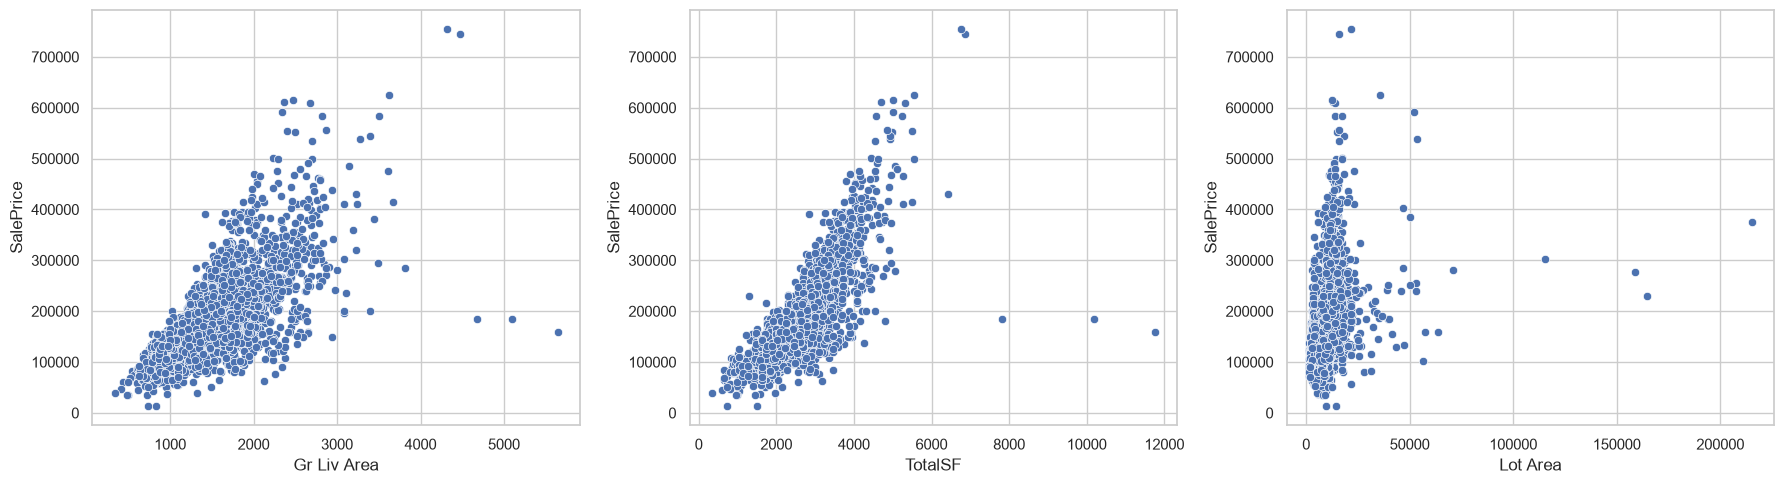

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_fe, x="Gr Liv Area", y="SalePrice", ax=axes[0])

sns.scatterplot(data=df_fe, x="TotalSF", y="SalePrice", ax=axes[1])

sns.scatterplot(data=df_fe, x="Lot Area", y="SalePrice", ax=axes[2])

plt.tight_layout()
plt.show()

In [34]:
# Numerical features
numeric_cols = df_fe.select_dtypes(
    include=["int64", "float64"]
).columns

skewness = df_fe[numeric_cols].skew().sort_values(
    ascending=False
)

skewness.head(20)

Misc Val           21.999788
Pool Area          16.939142
Lot Area           12.820898
Low Qual Fin SF    12.118162
3Ssn Porch         11.403795
Kitchen AbvGr       4.313825
BsmtFin SF 2        4.139978
Enclosed Porch      4.014446
Screen Porch        3.957467
Bsmt Half Bath      3.940795
Mas Vnr Area        2.606985
Open Porch SF       2.535386
Wood Deck SF        1.842678
SalePrice           1.743500
TotalSF             1.513266
Lot Frontage        1.499067
1st Flr SF          1.469429
BsmtFin SF 1        1.416182
TotalPorchSF        1.377215
MS SubClass         1.357579
dtype: float64

In [36]:
cols_to_check = [
    "SalePrice",
    "Lot Area",
    "Gr Liv Area",
    "TotalSF",
    "Total Bsmt SF",
    "1st Flr SF",
    "2nd Flr SF",
    "Garage Area",
    "TotalPorchSF"
]

df_fe[cols_to_check].skew().sort_values(ascending=False)

Lot Area         12.820898
SalePrice         1.743500
TotalSF           1.513266
1st Flr SF        1.469429
TotalPorchSF      1.377215
Gr Liv Area       1.274110
Total Bsmt SF     1.156204
2nd Flr SF        0.866457
Garage Area       0.241994
dtype: float64

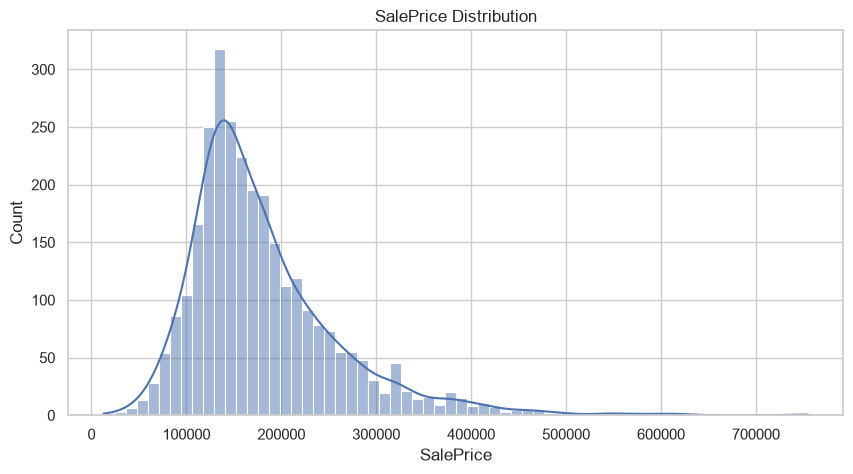

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_fe["SalePrice"],
    kde=True
)

plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.show()

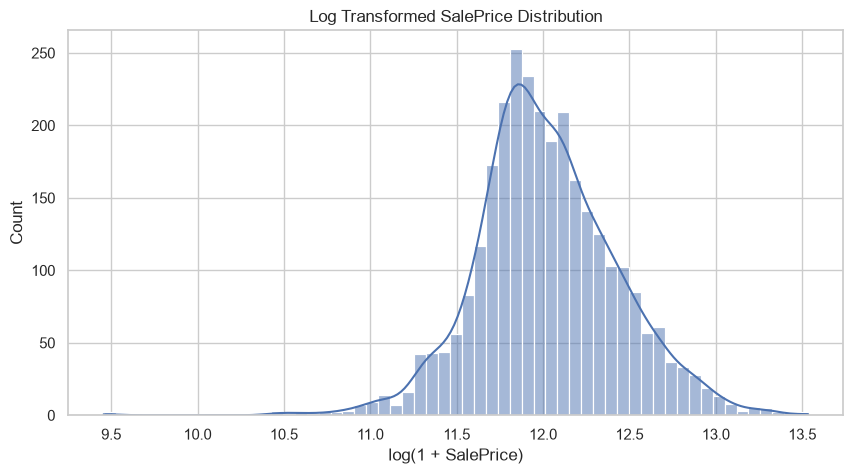

In [38]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(df_fe["SalePrice"]),
    kde=True
)

plt.title("Log Transformed SalePrice Distribution")
plt.xlabel("log(1 + SalePrice)")
plt.show()

## Investigating the extreme houses
#### This will let us answer:"Are these genuine houses or bad/outlier records?"
##### That's much better than blindly applying an outlier-removal rule.


In [39]:
df_fe.nlargest(
    10,
    "Gr Liv Area"
)[[
    "Gr Liv Area",
    "TotalSF",
    "Overall Qual",
    "Year Built",
    "SalePrice"
]]

,Gr Liv Area,TotalSF,Overall Qual,Year Built,SalePrice
1498,5642,11752.0,10,2008,160000
2180,5095,10190.0,10,2008,183850
2181,4676,7814.0,10,2007,184750
1760,4476,6872.0,10,1996,745000
1767,4316,6760.0,10,1994,755000
1497,3820,3820.0,5,1959,284700
2737,3672,5508.0,6,1935,415000
2445,3627,5557.0,10,1995,625000
2666,3608,4143.0,10,1892,475000
2450,3500,5233.0,9,1993,584500


In [40]:
df_fe.nlargest(
    10,
    "Lot Area"
)[[
    "Lot Area",
    "Gr Liv Area",
    "TotalSF",
    "Overall Qual",
    "SalePrice"
]]

,Lot Area,Gr Liv Area,TotalSF,Overall Qual,SalePrice
956,215245,2036,4172.0,7,375000
1570,164660,1786,3285.0,5,228950
2115,159000,2144,3588.0,6,277000
2071,115149,1824,3467.0,7,302000
2766,70761,1533,3066.0,7,280000
1498,63887,5642,11752.0,10,160000
314,57200,1687,2434.0,5,160000
1610,56600,1836,2522.0,5,103000
15,53504,3279,4929.0,8,538000
1402,53227,1663,3027.0,4,256000


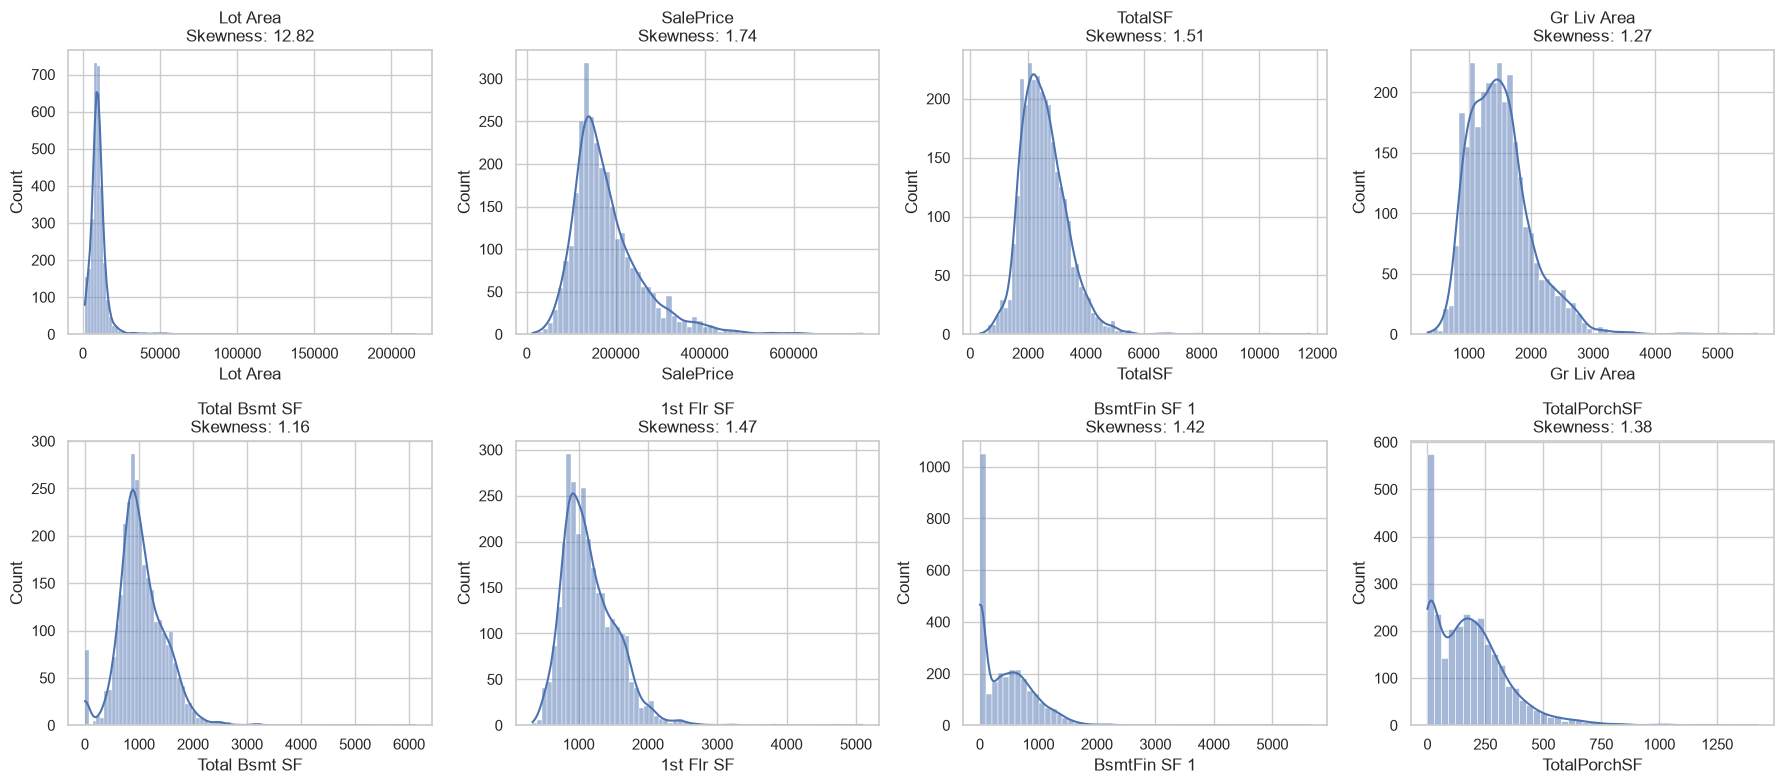

In [41]:
skewed_features = [
    "Lot Area",
    "SalePrice",
    "TotalSF",
    "Gr Liv Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "BsmtFin SF 1",
    "TotalPorchSF"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(axes.flat, skewed_features):
    sns.histplot(df_fe[col], kde=True, ax=ax)
    ax.set_title(f"{col}\nSkewness: {df_fe[col].skew():.2f}")

plt.tight_layout()
plt.show()


In [42]:
log_features = [
    "Lot Area",
    "TotalSF",
    "Gr Liv Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "BsmtFin SF 1",
    "TotalPorchSF"
]

for col in log_features:
    df_fe[f"Log_{col}"] = np.log1p(df_fe[col])

log_skewness = df_fe[
    [f"Log_{col}" for col in log_features]
].skew().sort_values(ascending=False)

log_skewness

Log_1st Flr SF       0.062356
Log_Gr Liv Area      0.016484
Log_TotalSF         -0.367814
Log_Lot Area        -0.498335
Log_BsmtFin SF 1    -0.622259
Log_TotalPorchSF    -1.358941
Log_Total Bsmt SF   -4.967089
dtype: float64

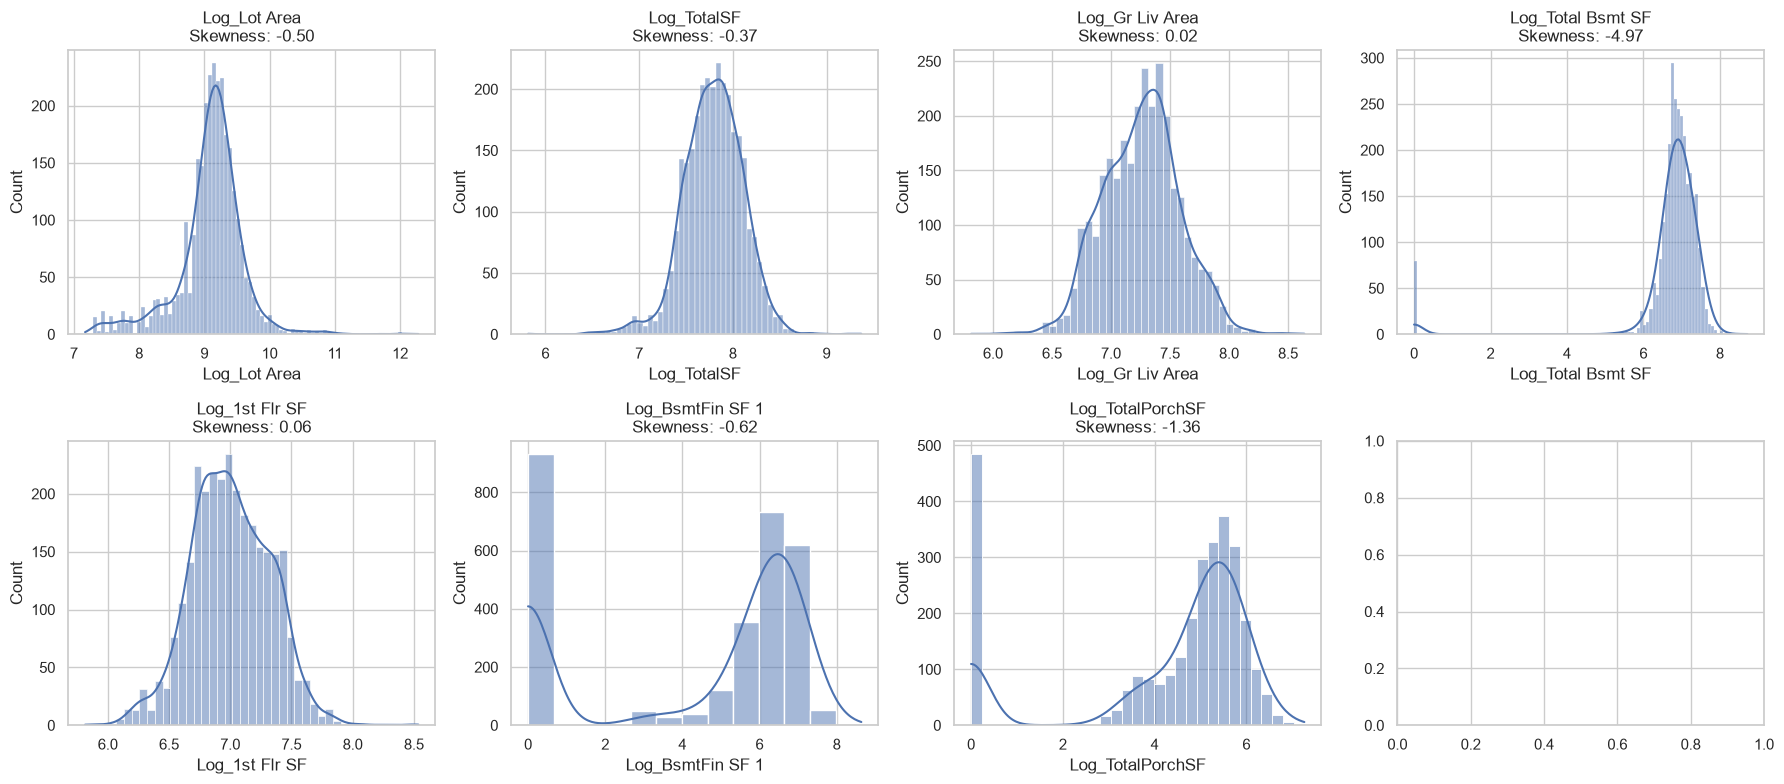

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, col in zip(
    axes.flat,
    [f"Log_{col}" for col in log_features]
):
    
    sns.histplot(df_fe[col], kde=True, ax=ax)
    
    ax.set_title(f"{col}\nSkewness: {df_fe[col].skew():.2f}")

plt.tight_layout()
plt.show()

In [50]:
# Then let's investigate zero inflation => This is important before we decide how to engineer features.

zero_counts =(df_fe[log_features].eq(0).sum().sort_values(ascending=False))
zero_percentage = (zero_counts / len(df_fe) *100).round(2)
pd.DataFrame({"Zero Count" : zero_counts, "Zero %": zero_percentage})

,Zero Count,Zero %
BsmtFin SF 1,930,31.74
TotalPorchSF,484,16.52
Total Bsmt SF,79,2.70
Gr Liv Area,0,0.00
TotalSF,0,0.00
Lot Area,0,0.00
1st Flr SF,0,0.00
